# Preprocessing Notebook
Here is where we take the data we got from 00_data and prepare it for machine learning modeling

In [2]:
### imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print('done!')

done!


### helper functions

### pull in the data and clean for analysis

In [3]:
df = pd.read_csv('../00_data/player_data.csv')

#show
df

,Unnamed: 0,index,Rk_x,Player,Age,Team,Pos,G,GS,MP_x,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,0,1.0,Shai Gilgeous-Alexander,26.0,OKC,PG,76.0,76.0,34.2,...,8.6,34.8,11.9,4.8,16.7,0.309,8.9,2.6,11.5,8.9
1,1,1,2.0,Giannis Antetokounmpo,30.0,MIL,PF,67.0,67.0,34.2,...,11.2,35.2,7.8,3.7,11.5,0.241,6.9,2.5,9.5,6.6
2,2,2,3.0,Nikola Jokić,29.0,DEN,C,70.0,70.0,36.7,...,12.8,29.5,12.7,3.8,16.4,0.307,9.9,3.3,13.3,9.8
3,3,4,4.0,Luka Dončić,25.0,DAL,PG,22.0,22.0,35.7,...,12.4,33.1,1.5,1.1,2.5,0.155,5.5,1.4,6.9,1.8
4,4,5,4.0,Luka Dončić,25.0,LAL,PG,28.0,28.0,35.1,...,13.5,34.5,2.0,1.4,3.4,0.164,5.5,1.1,6.5,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,649,730,565.0,Riley Minix,24.0,SAS,SF,1.0,0.0,7.0,...,0.0,6.1,0.0,0.0,0.0,-0.114,-8.5,-3.3,-11.8,0.0
650,650,731,566.0,Jahlil Okafor,29.0,IND,C,1.0,0.0,3.0,...,NaN,0.0,0.0,0.0,0.0,0.196,2.5,4.9,7.5,0.0
651,651,732,567.0,Zyon Pullin,23.0,MEM,SG,3.0,0.0,1.0,...,0.0,13.4,0.0,0.0,0.0,-0.304,-15.0,-7.7,-22.7,0.0
652,652,733,568.0,Isaiah Stevens,24.0,MIA,PG,3.0,0.0,2.0,...,0.0,14.8,0.0,0.0,0.0,-0.196,-19.5,7.7,-11.8,0.0


In [4]:
# trimming the columns that aren't numeric
df_numeric = df.select_dtypes(include='number')

# dropping the index, rank, unnamed column
df_numeric = df_numeric.drop(['Unnamed: 0', 'index', 'Rk_x', 'Rk_y', 'MP_y'], axis=1)

# show
df_numeric

,Age,G,GS,MP_x,FG,FGA,FG%,3P,3PA,3P%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,26.0,76.0,76.0,34.2,11.3,21.8,0.519,2.1,5.7,0.375,...,8.6,34.8,11.9,4.8,16.7,0.309,8.9,2.6,11.5,8.9
1,30.0,67.0,67.0,34.2,11.8,19.7,0.601,0.2,0.9,0.222,...,11.2,35.2,7.8,3.7,11.5,0.241,6.9,2.5,9.5,6.6
2,29.0,70.0,70.0,36.7,11.2,19.5,0.576,2.0,4.7,0.417,...,12.8,29.5,12.7,3.8,16.4,0.307,9.9,3.3,13.3,9.8
3,25.0,22.0,22.0,35.7,9.8,21.2,0.464,3.4,9.6,0.354,...,12.4,33.1,1.5,1.1,2.5,0.155,5.5,1.4,6.9,1.8
4,25.0,28.0,28.0,35.1,8.8,20.0,0.438,3.6,9.6,0.379,...,13.5,34.5,2.0,1.4,3.4,0.164,5.5,1.1,6.5,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,24.0,1.0,0.0,7.0,0.0,1.0,0.000,0.0,1.0,0.000,...,0.0,6.1,0.0,0.0,0.0,-0.114,-8.5,-3.3,-11.8,0.0
650,29.0,1.0,0.0,3.0,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,0.0,0.0,0.0,0.0,0.196,2.5,4.9,7.5,0.0
651,23.0,3.0,0.0,1.0,0.0,0.3,0.000,0.0,0.0,NaN,...,0.0,13.4,0.0,0.0,0.0,-0.304,-15.0,-7.7,-22.7,0.0
652,24.0,3.0,0.0,2.0,0.0,0.7,0.000,0.0,0.3,0.000,...,0.0,14.8,0.0,0.0,0.0,-0.196,-19.5,7.7,-11.8,0.0


In [5]:
# i wanna see how many NA's we have
df_numeric.info()

#seems there are a few columns with a few na values, but the data set should be large enough that if we just dropped them it shouldn't be an issue
df_cleaned = df_numeric.dropna()

df_cleaned

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 47 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       654 non-null    float64
 1   G         654 non-null    float64
 2   GS        654 non-null    float64
 3   MP_x      654 non-null    float64
 4   FG        654 non-null    float64
 5   FGA       654 non-null    float64
 6   FG%       650 non-null    float64
 7   3P        654 non-null    float64
 8   3PA       654 non-null    float64
 9   3P%       614 non-null    float64
 10  2P        654 non-null    float64
 11  2PA       654 non-null    float64
 12  2P%       643 non-null    float64
 13  eFG%      650 non-null    float64
 14  FT        654 non-null    float64
 15  FTA       654 non-null    float64
 16  FT%       613 non-null    float64
 17  ORB       654 non-null    float64
 18  DRB       654 non-null    float64
 19  TRB       654 non-null    float64
 20  AST       654 non-null    float6

,Age,G,GS,MP_x,FG,FGA,FG%,3P,3PA,3P%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,26.0,76.0,76.0,34.2,11.3,21.8,0.519,2.1,5.7,0.375,...,8.6,34.8,11.9,4.8,16.7,0.309,8.9,2.6,11.5,8.9
1,30.0,67.0,67.0,34.2,11.8,19.7,0.601,0.2,0.9,0.222,...,11.2,35.2,7.8,3.7,11.5,0.241,6.9,2.5,9.5,6.6
2,29.0,70.0,70.0,36.7,11.2,19.5,0.576,2.0,4.7,0.417,...,12.8,29.5,12.7,3.8,16.4,0.307,9.9,3.3,13.3,9.8
3,25.0,22.0,22.0,35.7,9.8,21.2,0.464,3.4,9.6,0.354,...,12.4,33.1,1.5,1.1,2.5,0.155,5.5,1.4,6.9,1.8
4,25.0,28.0,28.0,35.1,8.8,20.0,0.438,3.6,9.6,0.379,...,13.5,34.5,2.0,1.4,3.4,0.164,5.5,1.1,6.5,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,25.0,13.0,0.0,4.4,0.2,0.6,0.250,0.0,0.2,0.000,...,32.6,14.2,-0.1,0.1,-0.1,-0.066,-9.2,-1.3,-10.5,-0.1
639,25.0,22.0,0.0,3.9,0.2,1.2,0.192,0.1,0.7,0.200,...,9.8,15.7,-0.3,0.1,-0.2,-0.086,-7.5,-0.7,-8.1,-0.1
640,21.0,5.0,0.0,2.0,0.2,1.4,0.143,0.0,0.6,0.000,...,0.0,34.4,-0.1,0.0,-0.1,-0.473,-16.8,-8.2,-24.9,-0.1
641,23.0,5.0,0.0,1.6,0.2,1.2,0.167,0.0,0.6,0.000,...,13.4,40.2,-0.1,0.0,-0.1,-0.553,-21.9,-10.8,-32.7,-0.1


### eda for PER

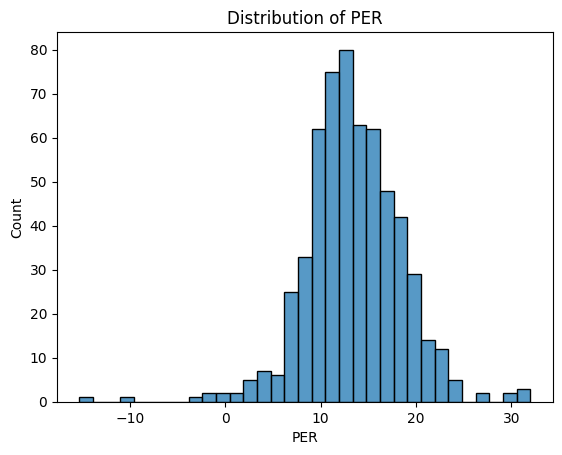

In [6]:
# the goal is to understand how PER is distributed, and also see which columns are related to it
# step one, show how PER is distributed
sns.histplot(data=df_cleaned, x='PER')
plt.title('Distribution of PER')
plt.show()

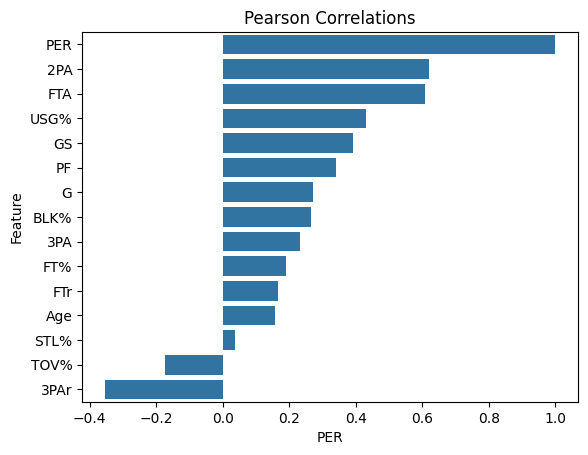

In [11]:
# now that we can see how PER is distributed, I want to see what stats correlate with it
# trimming out the stats that are used in the PER calculation
per_cols = ['MP_x', 'DRB%', 'FG', 'FGA', 'FT', '3P', 'PTS', 'AST', 'TRB', 'ORB', 'DRB', 'STL', 'BLK', 'TOV', # all are stats directly used in PER calculation
           'OBPM', 'BPM', 'WS/48', 'TS%', 'OWS', 'WS', 'DWS', 'FG%', 'VORP', 'eFG%', 'DBPM', 'AST%', 'TRB%', 'ORB%', '2P%', '3P%', '2P', 'Team_Win'] # these are all stats that use the same ingredients
df_per = df_cleaned.drop(per_cols, axis=1)

# remove stats that are also calculated using the same ingredients

# Pearson matrix
df_pearson = df_per.corr(method='pearson').sort_values(by='PER', ascending=False)

# Spearman matrix
df_spearman = df_per.corr(method='spearman').sort_values(by='PER', ascending=False)

sns.barplot(x=df_pearson['PER'], y=df_pearson.index)
plt.title('Pearson Correlations')
plt.ylabel('Feature')
plt.show()

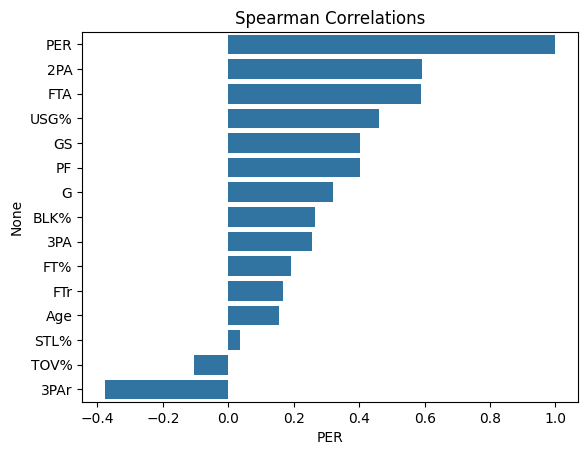

In [72]:
sns.barplot(x=df_spearman['PER'], y=df_pearson.index)
plt.title('Spearman Correlations')
plt.ylabel('Feature')
plt.show()

In [58]:
df_spearman.index

Index(['PER', '2PA', 'USG%', 'FTr', 'GS', 'PF', 'BLK%', 'G', 'Age', '3PA',
       'FT%', 'Team_Win', 'STL%', 'TOV%', '3PAr'],
      dtype='object')

### Win Shares EDA

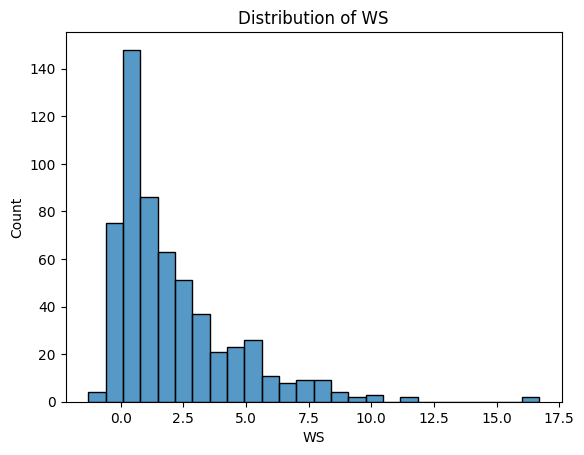

In [59]:
# the goal is to understand how WS is distributed, and also see which columns are related to it
# step one, show how WS is distributed
sns.histplot(data=df_cleaned, x='WS')
plt.title('Distribution of WS')
plt.show()

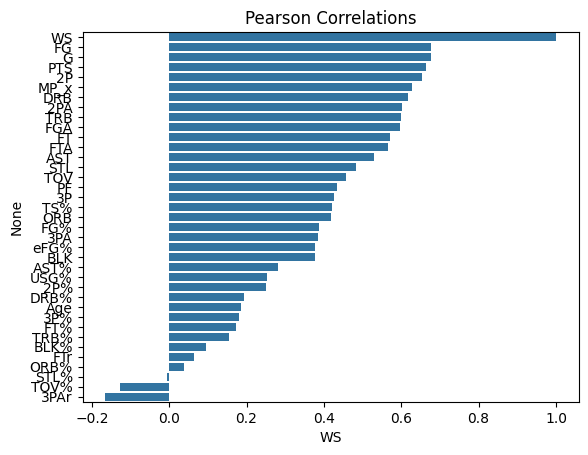

In [68]:
# now that we can see how PER is distributed, I want to see what stats correlate with it
# trimming out the stats that are used in the PER calculation
ws_cols = ['OWS', 'DWS', 'VORP', 'GS', 'BPM', 'OBPM', 'DBPM', 'Team_Win', 'WS/48', 'PER'] # these are all stats that use the same ingredients
df_ws = df_cleaned.drop(ws_cols, axis=1)

# Pearson matrix
df_pearson = df_ws.corr(method='pearson').sort_values(by='WS', ascending=False)

# Spearman matrix
df_spearman = df_ws.corr(method='spearman').sort_values(by='WS', ascending=False)

sns.barplot(x=df_pearson['WS'], y=df_pearson.index)
plt.title('Pearson Correlations')
plt.ylabel('Feature')
plt.show()

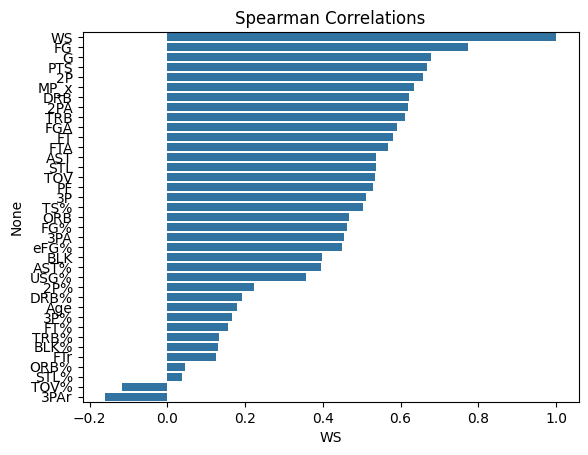

In [70]:
sns.barplot(x=df_spearman['WS'], y=df_pearson.index)
plt.title('Spearman Correlations')
plt.ylabel('Feature')
plt.show()

### making numeric data set with name as well

In [78]:
df_final = df.select_dtypes(include='number').assign(Player=df['Player'])

# dropping the index, rank, unnamed column
df_final = df_final.drop(['Unnamed: 0', 'index', 'Rk_x', 'Rk_y', 'MP_y'], axis=1)

df_final.dropna(inplace=True)

df_final.to_csv('./df_final.csv')